In [1]:
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -----------------------------
# 1) JCIM-style rcParams
# -----------------------------
def set_jcim_style():
    mpl.rcParams.update({
        # Font
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,

        # Font sizes
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.fontsize": 8.5,

        # Lines
        "axes.linewidth": 0.9,
        "lines.linewidth": 1.6,
        "lines.markersize": 5,

        # Ticks
        "xtick.major.size": 3.5,
        "ytick.major.size": 3.5,
        "xtick.major.width": 0.9,
        "ytick.major.width": 0.9,
        "xtick.minor.size": 2.0,
        "ytick.minor.size": 2.0,
        "xtick.minor.width": 0.7,
        "ytick.minor.width": 0.7,
        "xtick.direction": "out",
        "ytick.direction": "out",

        # Export
        "figure.dpi": 100,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    })

set_jcim_style()

# -----------------------------
# 2) Final figure sizes
# -----------------------------
SINGLE_COL_IN = 4
H_MED   = 3.4

# -----------------------------
# 3) Color map
# -----------------------------
color_map = {
    "PepINVENT":        "#000000",
    "PepEVOLVE - NM":   "#E69F00",
    "PepEVOLVE - NS":   "#56B4E9",
    "PepEVOLVE - SM":   "#009E73",
    "PepEVOLVE - SS":   "#D55E00",
    "GA":               "#882255",
}

# -----------------------------
# 4) Shared data-loading helpers
# -----------------------------
base_dir = "../../output/journal/result"

def load_single_run(base_dir, mode, run):
    folder = os.path.join(base_dir, f"{mode}{run}")
    if mode.startswith("pepinvent"):
        csv_path = os.path.join(folder, "results.csv")
    elif mode.startswith("traditional_ga"):
        csv_path = os.path.join(folder, "results_evolving_step1000.csv")
    else:
        csv_path = os.path.join(folder, "results_evolving_step250.csv")

    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        df['Step'] = df['Step'].astype(int)
        return df
    else:
        print(f"  Missing: {csv_path}")
        return None

def compute_mean_of_means(base_dir, mode):
    run_means = []
    for run in [1, 2, 3]:
        df = load_single_run(base_dir, mode, run)
        if df is not None:
            mean_per_step = df.groupby('Step')['total_score'].mean()
            run_means.append(mean_per_step)
    if not run_means:
        return None
    aligned = pd.concat(run_means, axis=1)
    return aligned.mean(axis=1)

# 1. Pretraining Loss

/tmp/ipykernel_2175807/3534584868.py:58: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


✅ Figure saved to: ../../figure_pdf/pretraining_loss.pdf


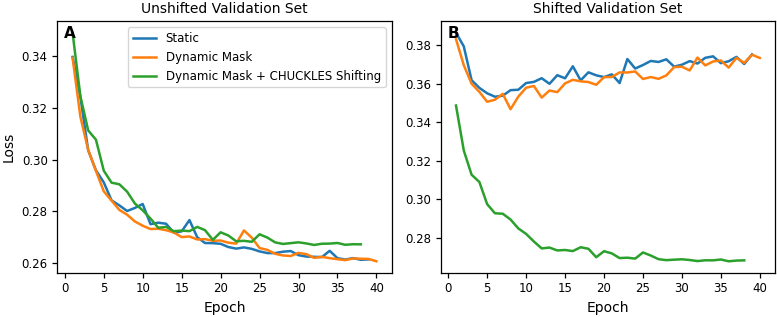

In [2]:
import re
import matplotlib.pyplot as plt

def extract_validation_losses(log_file_path):
    """
    Extracts Validation loss 1 and 2 from the given log file.
    """
    pattern = re.compile(
        r"Train loss, Validation loss, Validation loss 2, .*: [\d.]+, ([\d.]+), ([\d.]+)"
    )
    val1, val2 = [], []

    with open(log_file_path, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                val1.append(float(match.group(1)))
                val2.append(float(match.group(2)))
    return val1, val2


def plot_split_validation_losses(log_paths, labels, save_path=None):
    """
    Plots Validation Loss 1 and Validation Loss 2 from multiple training modes
    in two side-by-side subplots for compact article-style display.
    Optionally saves the figure to disk with high DPI.
    """
    fig, axes = plt.subplots(1, 2, figsize=(SINGLE_COL_IN*2, H_MED), constrained_layout=True)

    colors = ['tab:blue', 'tab:orange', 'tab:green']  # consistent color scheme

    # --- Validation Loss 1 ---
    for path, label, color in zip(log_paths, labels, colors):
        val1, val2 = extract_validation_losses(path)
        if not val1:
            print(f"⚠️ No validation losses found in {path}")
            continue
        epochs = range(1, len(val1) + 1)
        axes[0].plot(epochs, val1, label=label, color=color, linewidth=1.8)
    axes[0].set_title("Unshifted Validation Set")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].text(0.02, 0.98, "A", transform=axes[0].transAxes, va="top", ha="left", fontsize=11, fontweight="bold")
    axes[0].legend()

    # --- Validation Loss 2 ---
    for path, label, color in zip(log_paths, labels, colors):
        val1, val2 = extract_validation_losses(path)
        if not val2:
            continue
        epochs = range(1, len(val2) + 1)
        axes[1].plot(epochs, val2, label=label, color=color, linewidth=1.8)
    axes[1].set_title("Shifted Validation Set")
    axes[1].set_xlabel("Epoch")
    axes[1].text(0.02, 0.98, "B", transform=axes[1].transAxes, va="top", ha="left", fontsize=11, fontweight="bold")
    # axes[1].legend()

    plt.tight_layout()

    # --- Save high-DPI figure ---
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')  # 300 DPI for print-quality
        print(f"✅ Figure saved to: {save_path}")

    plt.show()


# Example usage
plot_split_validation_losses(
    [
        "../../checkpoint/static/train_model.log",
        "../../checkpoint/dynamic_mask/train_model.log",
        "../../checkpoint/dynamic_mask_shift/train_model.log"
    ],
    ["Static", "Dynamic Mask", "Dynamic Mask + CHUCKLES Shifting"],
    save_path="../../figure_pdf/pretraining_loss.pdf"  # <- save here
)

# 2. Masking Percentage

In [3]:
import random 
import matplotlib.pyplot as plt
import numpy as np

def get_num_mask(chuckles: str):
    monomers = chuckles.split('|')
    return round(random.triangular(1, len(monomers)*0.4, 0))

with open("../../data/train_data/train_filled_chuckles.txt", "r") as file:
    chuckles_data = [x.strip() for x in file.readlines()]

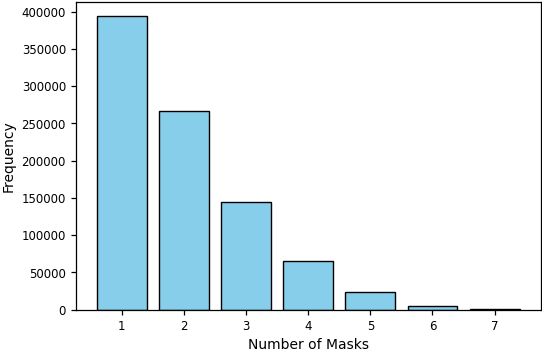

In [4]:
num_masks = [get_num_mask(x) for x in chuckles_data]
# Compute frequencies of each unique value
unique, counts = np.unique(num_masks, return_counts=True)

plt.figure(figsize=(6, 4))
plt.bar(unique, counts, color='skyblue', edgecolor='black')
plt.xlabel("Number of Masks")
plt.ylabel("Frequency")
plt.xticks(unique)
# plt.savefig("../../figure_pdf/mask_distribution.png", dpi=600, bbox_inches='tight')
plt.show()

Text(0.5, 1.0, 'Distribution of Number of Masks in PepInvent Dataset')

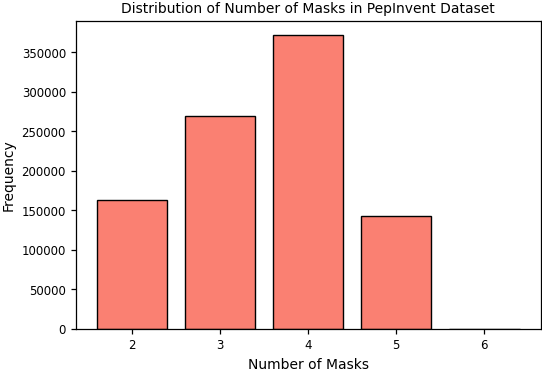

In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

pepinvent_train = pd.read_csv('../../data/train_data/original/train.csv')
pepinvent_val = pd.read_csv('../../data/train_data/original/val.csv')

pepinvent = pd.concat([pepinvent_train, pepinvent_val], ignore_index=True)
pepinvent['num_mask'] = pepinvent['Target_Mol'].apply(lambda x: len(x.split('|')))

plt.figure(figsize=(6, 4))
plt.bar(pepinvent['num_mask'].value_counts().index, pepinvent['num_mask'].value_counts().values, color='salmon', edgecolor='black')
plt.xlabel("Number of Masks")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Masks in PepInvent Dataset")
# plt.savefig("../../figure_pdf/pepinvent_mask_distribution.png", dpi=600, bbox_inches='tight')

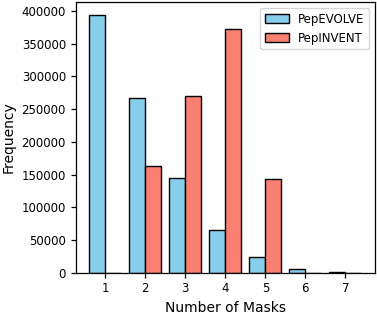

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt

# Distribution of Number of Masks: PepEVOLVE vs PepINVENT
unique_pepevolve, counts_pepevolve = np.unique(num_masks, return_counts=True)
unique_pepinvent, counts_pepinvent = np.unique(pepinvent['num_mask'], return_counts=True)

x = np.arange(1, max(unique_pepevolve.max(), unique_pepinvent.max()) + 1)
width = 0.4

fig, ax = plt.subplots(figsize=(SINGLE_COL_IN*1, H_MED))

bars1 = ax.bar(x - width/2, 
               [counts_pepevolve[unique_pepevolve == i][0] if i in unique_pepevolve else 0 for i in x],
               width, label='PepEVOLVE', color='skyblue', edgecolor='black')

bars2 = ax.bar(x + width/2, 
               [counts_pepinvent[unique_pepinvent == i][0] if i in unique_pepinvent else 0 for i in x],
               width, label='PepINVENT', color='salmon', edgecolor='black')

ax.set_xlabel("Number of Masks")
ax.set_ylabel("Frequency")
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.savefig("../../figure_pdf/mask_distribution_comparison.pdf", dpi=600, bbox_inches='tight')
plt.show()

# 3. Router policy distribution

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

def plot_categorical_evolution(distributions, save_path=None):
    # Convert list of arrays into 2D NumPy array (T × C)
    data = np.vstack(distributions)
    timesteps, categories = data.shape

    # plt.figure(figsize=(max(6, categories/2), max(3, timesteps/100)), dpi=600)
    plt.figure(figsize=(SINGLE_COL_IN, H_MED), dpi=600)
    im = plt.imshow(
        data,
        aspect='auto',
        interpolation='bilinear',  # or 'bicubic' for even smoother
        origin='upper',
        vmin=0.0,
        vmax=1.0,
        cmap='summer'
    )
    plt.colorbar(im, label='Probability')

    # plt.title(f'Router Optimal Position Distribution')
    plt.xlabel('Positions')
    plt.ylabel('Steps')

    # Reduce tick clutter for large numbers
    plt.xticks(range(categories))
    yticks = np.arange(0, timesteps, 50)
    plt.yticks(ticks=yticks, labels=[str(i) for i in yticks])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=600)
    else:
        plt.show()
    plt.close()

In [ ]:
hbd_1pos = np.load('../../output/preprint/logging/hbd_1pos/router_ps.npy', allow_pickle=True)
hbd_2pos = np.load('../../output/preprint/logging/hbd_2pos/router_ps.npy', allow_pickle=True)

logp_luna18_1pos = np.load('../../output/preprint/logging/logp_luna18_1pos/router_ps.npy', allow_pickle=True)
logp_luna18_2pos = np.load('../../output/preprint/logging/logp_luna18_2pos/router_ps.npy', allow_pickle=True)
logp_luna18_2pos_adversarial = np.load('../../output/preprint/logging/logp_luna18_2pos_adversarial/router_ps.npy', allow_pickle=True)

In [ ]:
plot_categorical_evolution(hbd_1pos, save_path='../../figure_pdf/cmapsummer_hbd_1pos.pdf')
plot_categorical_evolution(hbd_2pos, save_path='../../figure_pdf/cmapsummer_hbd_2pos.pdf')

In [ ]:
plot_categorical_evolution(logp_luna18_1pos, save_path='../../figure_pdf/cmapsummer_logp_luna18_1pos.pdf')
plot_categorical_evolution(logp_luna18_2pos, save_path='../../figure_pdf/cmapsummer_logp_luna18_2pos.pdf')

In [ ]:
plot_categorical_evolution(logp_luna18_2pos_adversarial, save_path='../../figure_pdf/cmapsummer_logp_luna18_2pos_adversarial.pdf')

# 5. Ablation

Using result directory: ../../output/journal/result
  nm: modes=['nm_cs_topk', 'nm_pepevolve', 'nm_topk', 'nm_topk_gra', 'pepinvent', 'pepinvent_cs']
  ns: modes=['ns_cs_topk', 'ns_pepevolve', 'ns_topk', 'ns_topk_gra', 'pepinvent', 'pepinvent_cs']
  sm: modes=['pepinvent', 'pepinvent_cs', 'sm_cs_topk', 'sm_pepevolve', 'sm_topk', 'sm_topk_gra']
  ss: modes=['pepinvent', 'pepinvent_cs', 'ss_cs_topk', 'ss_pepevolve', 'ss_topk', 'ss_topk_gra']
Legend keys: ['cs_topk', 'pepevolve', 'topk', 'topk_gra', 'pepinvent', 'pepinvent_cs']


/tmp/ipykernel_2175807/2524976319.py:132: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


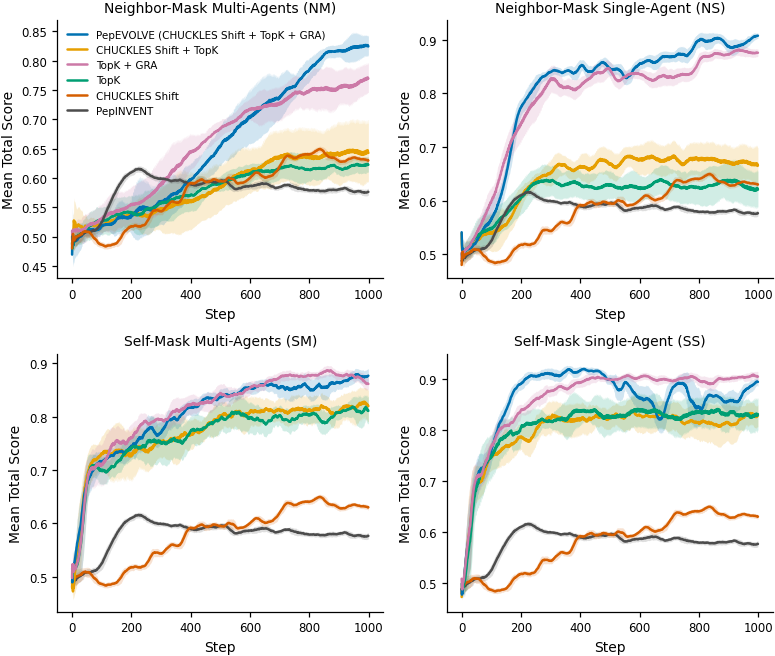

In [8]:
set_jcim_style()

print(f"Using result directory: {base_dir}")

SETTINGS = ['nm', 'ns', 'sm', 'ss']
SETTING_TITLES = {
    'nm': 'Neighbor-Mask Multi-Agents (NM)',
    'ns': 'Neighbor-Mask Single-Agent (NS)',
    'sm': 'Self-Mask Multi-Agents (SM)',
    'ss': 'Self-Mask Single-Agent (SS)'
}

ABLATION_LABEL_ORDER = ['pepevolve', 'cs_topk', 'topk_gra', 'topk', 'pepinvent_cs', 'pepinvent']

ABLATION_LABELS = {
    'pepevolve': 'PepEVOLVE (CHUCKLES Shift + TopK + GRA)',
    'cs_topk':   'CHUCKLES Shift + TopK',
    'topk_gra':  'TopK + GRA',
    'topk':      'TopK',
    'pepinvent_cs': 'CHUCKLES Shift',
    'pepinvent': 'PepINVENT'
}

ABLATION_COLORS = {
    'pepevolve': "#0072B2",
    'cs_topk':   "#E69F00",
    'topk':      "#009E73",
    'topk_gra':  "#CC79A7",
    'pepinvent_cs': "#D55E00",
    'pepinvent': "#4C4C4C"
}

def get_ablation_type(mode, setting):
    if mode.startswith("pepinvent"):
        return mode
    prefix = f"{setting}_"
    if mode.startswith(prefix):
        return mode[len(prefix):]
    return mode

def ablation_compute_mean_of_means(base_dir, mode):
    mean_series = compute_mean_of_means(base_dir, mode)
    if mean_series is None:
        return None
    max_step = int(mean_series.index.max())
    return mean_series.reindex(range(0, max_step + 1)).interpolate()

fig, axes = plt.subplots(2, 2, figsize=(SINGLE_COL_IN*2, H_MED*2), constrained_layout=True)

legend_handles = {}

for ax, setting in zip(axes.flat, SETTINGS):

    all_folders = [f for f in os.listdir(base_dir)
                   if os.path.isdir(os.path.join(base_dir, f))]

    all_folders = [f for f in all_folders
                   if f.startswith(setting + "_")
                   or f.startswith("pepinvent")]

    mode_set = set()
    for folder in all_folders:
        mode = folder.rstrip('123')
        mode_set.add(mode)

    modes = sorted(mode_set)
    print(f"  {setting}: modes={modes}")

    mean_scores = {}
    mean_stds = {}

    for mode in modes:
        mean_series = ablation_compute_mean_of_means(base_dir, mode)
        if mean_series is None:
            print(f"    SKIP {mode} (no data)")
            continue

        mean_series_roll = mean_series.rolling(window=30, min_periods=1)
        mean_series_mean = mean_series_roll.mean()
        mean_series_std = mean_series_roll.std(ddof=0).fillna(0.0)

        mean_scores[mode] = mean_series_mean
        mean_stds[mode] = mean_series_std

    for mode, series in mean_scores.items():
        abl_type = get_ablation_type(mode, setting)
        color = ABLATION_COLORS.get(abl_type, 'black')
        display_label = ABLATION_LABELS.get(abl_type, abl_type)
        std_series = mean_stds[mode]

        line, = ax.plot(
            series.index,
            series.values,
            linewidth=1.8,
            color=color,
            solid_capstyle='round',
        )
        ax.fill_between(
            series.index,
            series.values - std_series,
            series.values + std_series,
            color=color,
            linewidth=0,
            alpha=0.18)

        if abl_type not in legend_handles:
            legend_handles[abl_type] = (line, display_label)

    ax.set_title(SETTING_TITLES[setting])
    ax.set_xlabel("Step")
    ax.set_ylabel("Mean Total Score")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

print(f"Legend keys: {list(legend_handles.keys())}")

ordered_handles = [
    legend_handles[k] for k in ABLATION_LABEL_ORDER if k in legend_handles
]

lines = [h[0] for h in ordered_handles]
labels = [h[1] for h in ordered_handles]

axes.flat[0].legend(
    lines,
    labels,
    fontsize='small',
    loc='best',
    frameon=False,
)

plt.tight_layout()

plt.savefig(
    "../../figure_pdf/ablation_2x2.pdf",
    bbox_inches='tight',
)

plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np

base_dir = "../../output/journal/result"

SETTINGS = ['nm', 'ns', 'sm', 'ss']
ABLATION_TYPES = ['pepevolve', 'cs_topk', 'topk', 'topk_gra', 'pepinvent', 'pepinvent_cs']

def load_runs(base_dir, mode):
    dfs = []
    for run in [1, 2, 3]:
        folder = os.path.join(base_dir, f"{mode}{run}")
        csv_path = os.path.join(folder, "results.csv" if mode.startswith("pepinvent") else "results_evolving_step250.csv")
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df['run'] = run
            dfs.append(df)
        else:
            print(f"  ⚠️ Missing: {csv_path}")
    return pd.concat(dfs, ignore_index=True) if dfs else None

def get_unique_smiles_avg_score(combined):
    return combined.groupby('SMILES')['total_score'].mean()

def get_ablation_type(mode, setting):
    if mode.startswith("pepinvent"):
        return mode
    prefix = f"{setting}_"
    if mode.startswith(prefix):
        return mode[len(prefix):]
    return mode

# ── Collect scores ────────────────────────────────────────────────────────────
results = {abl: {} for abl in ABLATION_TYPES}

for setting in SETTINGS:
    all_folders = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f))]
    setting_folders = [f for f in all_folders if f.startswith(setting + "_")]
    mode_set = set(f.rstrip('123') for f in setting_folders)

    for mode in sorted(mode_set):
        combined = load_runs(base_dir, mode)
        if combined is None:
            continue
        abl_type = get_ablation_type(mode, setting)
        avg_scores = get_unique_smiles_avg_score(combined).sort_values(ascending=False)
        results[abl_type][setting] = avg_scores

for pi_mode in ['pepinvent', 'pepinvent_cs']:
    combined = load_runs(base_dir, pi_mode)
    if combined is not None:
        avg_scores = get_unique_smiles_avg_score(combined).sort_values(ascending=False)
        results[pi_mode]['_global'] = avg_scores

# ── Build tables ──────────────────────────────────────────────────────────────
def get_topk_mean_std(scores, k):
    if scores is None:
        return np.nan, np.nan
    top = scores.iloc[:k] if len(scores) >= k else scores
    return round(top.mean(), 4), round(top.std(), 4)

def build_topk_table_numeric(results, k):
    """Returns a DataFrame with numeric mean values (for finding max per column)."""
    setting_ablations = [a for a in ABLATION_TYPES if not a.startswith("pepinvent")]
    pepinvent_ablations = [a for a in ABLATION_TYPES if a.startswith("pepinvent")]
    rows = []

    for abl in setting_ablations:
        row = {'ablation': abl}
        for setting in SETTINGS:
            scores = results[abl].get(setting)
            mean, std = get_topk_mean_std(scores, k)
            row[f"{setting}_mean"] = mean
            row[f"{setting}_std"] = std
        rows.append(row)

    for abl in pepinvent_ablations:
        scores = results[abl].get('_global')
        mean, std = get_topk_mean_std(scores, k)
        row = {'ablation': abl}
        for setting in SETTINGS:
            row[f"{setting}_mean"] = mean
            row[f"{setting}_std"] = std
        rows.append(row)

    return pd.DataFrame(rows).set_index('ablation')

BOLD_GREEN  = "\033[1;32m"
BOLD_YELLOW = "\033[1;33m"
RESET       = "\033[0m"

def print_topk_table_colored(results, k):
    df = build_topk_table_numeric(results, k)

    # Find best and second-best (max mean) row index per setting column
    best_per_setting = {}
    second_per_setting = {}
    for setting in SETTINGS:
        col = df[f"{setting}_mean"].dropna()
        sorted_idx = col.sort_values(ascending=False).index
        best_per_setting[setting] = sorted_idx[0] if len(sorted_idx) >= 1 else None
        second_per_setting[setting] = sorted_idx[1] if len(sorted_idx) >= 2 else None

    col_width = 22
    header = f"{'ablation':<15}" + "".join(f"{s:>{col_width}}" for s in SETTINGS)
    print(header)
    print("-" * (15 + col_width * len(SETTINGS)))

    for abl in df.index:
        row_str = f"{abl:<15}"
        for setting in SETTINGS:
            mean = df.loc[abl, f"{setting}_mean"]
            std  = df.loc[abl, f"{setting}_std"]
            if np.isnan(mean):
                cell = "N/A"
            else:
                cell = f"{mean:.4f} ± {std:.4f}"
            # Highlight best in green, second-best in yellow
            if abl == best_per_setting[setting]:
                cell = f"{BOLD_GREEN}{cell}{RESET}"
                row_str += f"{cell:>{col_width + len(BOLD_GREEN) + len(RESET)}}"
            elif abl == second_per_setting[setting]:
                cell = f"{BOLD_YELLOW}{cell}{RESET}"
                row_str += f"{cell:>{col_width + len(BOLD_YELLOW) + len(RESET)}}"
            else:
                row_str += f"{cell:>{col_width}}"
        print(row_str)

print("=" * 70)
print(f"TOP-1 MEAN ± STD SCORE")
print("=" * 70)
print_topk_table_colored(results, k=1)

print("\n" + "=" * 70)
print(f"TOP-10 MEAN ± STD SCORE")
print("=" * 70)
print_topk_table_colored(results, k=10)

# 6. (Average runs) PepEVOLVE vs PepINVENT

In [18]:
set_jcim_style()

SINGLE_COL_IN = 4
H_MED   = 3.4

PEPEVOLVE_COLORS = {
    'nm': '#E69F00',
    'ns': '#56B4E9',
    'sm': '#009E73',
    'ss': '#D55E00',
}
PEPINVENT_COLOR = '#000000'
TGA_COLOR = '#882255'

SETTING_LABELS = {
    'nm': 'PepEVOLVE - NM',
    'ns': 'PepEVOLVE - NS',
    'sm': 'PepEVOLVE - SM',
    'ss': 'PepEVOLVE - SS',
}

def load_runs(base_dir, mode):
    dfs = []
    for run in [1, 2, 3]:
        folder = os.path.join(base_dir, f"{mode}{run}")
        if mode.startswith("pepinvent"):
            csv_path = os.path.join(folder, "results.csv")
        elif mode.startswith("traditional_ga"):
            csv_path = os.path.join(folder, "results_evolving_step1000.csv")
        else:
            csv_path = os.path.join(folder, "results_evolving_step250.csv")
        if os.path.exists(csv_path):
            df = pd.read_csv(csv_path)
            df['run'] = run
            dfs.append(df)
        else:
            print(f"  Missing: {csv_path}")
    return pd.concat(dfs, ignore_index=True) if dfs else None

def get_unique_smiles_avg_score(combined):
    return combined.groupby('SMILES')['total_score'].mean()

# Load data
pepevolve_scores = {}
for setting in SETTINGS:
    mode = f"{setting}_pepevolve"
    combined = load_runs(base_dir, mode)
    if combined is not None:
        pepevolve_scores[setting] = get_unique_smiles_avg_score(combined)

combined_pepinvent = load_runs(base_dir, "pepinvent")
pepinvent_avg_scores = None
if combined_pepinvent is not None:
    pepinvent_avg_scores = get_unique_smiles_avg_score(combined_pepinvent)

combined_tga = load_runs(base_dir, "traditional_ga")
tga_avg_scores = None
if combined_tga is not None:
    tga_avg_scores = get_unique_smiles_avg_score(combined_tga)

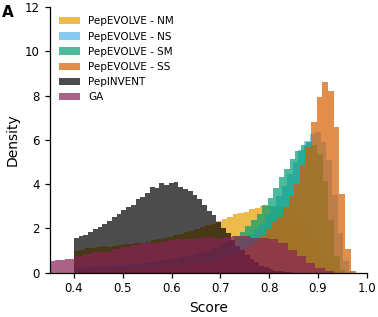

In [19]:
SCORE_MIN = 0.35

fig, ax = plt.subplots(figsize=(SINGLE_COL_IN, H_MED))

legend_handles = {}

for setting in SETTINGS:
    if setting not in pepevolve_scores:
        continue
    color = PEPEVOLVE_COLORS[setting]
    label = SETTING_LABELS[setting]
    n, bins_, patches = ax.hist(pepevolve_scores[setting], bins=50, alpha=0.7, color=color, density=True)
    legend_handles[f'pepevolve_{setting}'] = (patches[0], label)

if pepinvent_avg_scores is not None:
    n, bins_, patches = ax.hist(pepinvent_avg_scores, bins=50, alpha=0.7, color=PEPINVENT_COLOR, density=True)
    legend_handles['pepinvent'] = (patches[0], 'PepINVENT')

if tga_avg_scores is not None:
    n, bins_, patches = ax.hist(tga_avg_scores, bins=50, alpha=0.7, color=TGA_COLOR, density=True)
    legend_handles['tga'] = (patches[0], 'GA')

ax.set_xlabel("Score")
ax.set_ylabel("Density")
ax.set_xlim(SCORE_MIN, 1.0)
ax.set_ylim(0, 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-0.15, 0.95, "A", transform=ax.transAxes,
        va="bottom", ha="left", fontsize=11, fontweight="bold")
ordered_keys = [f'pepevolve_{s}' for s in SETTINGS] + ['pepinvent', 'tga']
ordered_handles = [legend_handles[k] for k in ordered_keys if k in legend_handles]
patch_list = [h[0] for h in ordered_handles]
label_list = [h[1] for h in ordered_handles]

ax.legend(
    patch_list, label_list,
    fontsize='small',
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.savefig("../../figure_pdf/average_score_distribution.pdf", bbox_inches='tight')
plt.show()

In [20]:
set_jcim_style()

TGA_COLOR = "#882255"

SETTINGS = ['nm', 'ns', 'sm', 'ss']
SETTING_TITLES = {
    'nm': 'NM',
    'ns': 'NS',
    'sm': 'SM',
    'ss': 'SS'
}

PEPEVOLVE_COLORS = {
    'nm': '#E69F00',
    'ns': '#56B4E9',
    'sm': '#009E73',
    'ss': '#D55E00',
}
PEPINVENT_COLOR = '#000000'

def compute_mean_and_std_across_runs(base_dir, mode):
    """Returns (mean, std) across 3 replicate runs at each step."""
    run_means = []
    for run in [1, 2, 3]:
        df = load_single_run(base_dir, mode, run)
        if df is not None:
            run_means.append(df.groupby('Step')['total_score'].mean())
    if not run_means:
        return None, None
    aligned = pd.concat(run_means, axis=1)
    return aligned.mean(axis=1), aligned.std(axis=1, ddof=1).fillna(0.0)

# Load data with inter-replicate std
pepevolve_means = {}
pepevolve_stds = {}
for setting in SETTINGS:
    mode = f"{setting}_pepevolve"
    mean_s, std_s = compute_mean_and_std_across_runs(base_dir, mode)
    if mean_s is not None:
        pepevolve_means[setting] = mean_s
        pepevolve_stds[setting] = std_s

mean_series_pepinvent, std_series_pepinvent = compute_mean_and_std_across_runs(base_dir, "pepinvent")
mean_series_tga, std_series_tga = compute_mean_and_std_across_runs(base_dir, "traditional_ga")

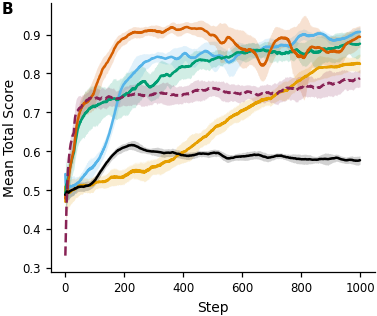

In [21]:
fig, ax = plt.subplots(figsize=(SINGLE_COL_IN, H_MED))

legend_handles = {}

for setting in SETTINGS:
    if setting not in pepevolve_means:
        continue
    mean_series = pepevolve_means[setting]
    std_series = pepevolve_stds[setting]
    smooth_mean = mean_series.rolling(window=30, min_periods=1).mean()
    smooth_std = std_series.rolling(window=30, min_periods=1).mean()
    label = f"PepEVOLVE - {SETTING_TITLES[setting].upper()}"
    line, = ax.plot(
        smooth_mean.index,
        smooth_mean,
        linewidth=1.8,
        color=PEPEVOLVE_COLORS[setting],
        label=label,
        solid_capstyle='round'
    )
    ax.fill_between(
        smooth_mean.index,
        smooth_mean - smooth_std,
        smooth_mean + smooth_std,
        color=PEPEVOLVE_COLORS[setting],
        alpha=0.18,
        linewidth=0
    )
    legend_handles[f"pepevolve_{setting}"] = (line, label)

# PepINVENT
if mean_series_pepinvent is not None:
    smooth_mean = mean_series_pepinvent.rolling(window=30, min_periods=1).mean()
    smooth_std = std_series_pepinvent.rolling(window=30, min_periods=1).mean()
    label = "PepINVENT"
    line, = ax.plot(smooth_mean.index, smooth_mean, linewidth=1.8, color=PEPINVENT_COLOR, solid_capstyle='round')
    ax.fill_between(smooth_mean.index, smooth_mean - smooth_std, smooth_mean + smooth_std, color=PEPINVENT_COLOR, alpha=0.18, linewidth=0)
    legend_handles["pepinvent"] = (line, label)

# GA
if mean_series_tga is not None:
    smooth_mean = mean_series_tga.rolling(window=30, min_periods=1).mean()
    smooth_std = std_series_tga.rolling(window=30, min_periods=1).mean()
    label = "GA"
    line, = ax.plot(smooth_mean.index, smooth_mean, linewidth=1.8, color=TGA_COLOR, solid_capstyle='round', linestyle='--')
    ax.fill_between(smooth_mean.index, smooth_mean - smooth_std, smooth_mean + smooth_std, color=TGA_COLOR, alpha=0.18, linewidth=0)
    legend_handles["tga"] = (line, label)

ax.set_xlabel("Step")
ax.set_ylabel("Mean Total Score")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-0.15, 0.95, "B", transform=ax.transAxes,
        va="bottom", ha="left", fontsize=11, fontweight="bold")

ordered_keys = [f"pepevolve_{s}" for s in SETTINGS] + ["pepinvent", "tga"]
ordered_handles = [legend_handles[k] for k in ordered_keys if k in legend_handles]
lines = [h[0] for h in ordered_handles]
labels = [h[1] for h in ordered_handles]

# ax.legend(lines, labels, fontsize='small', loc='lower right', frameon=False)

plt.tight_layout()
plt.savefig(
    "../../figure_pdf/average_score_linegraph_all_raw.pdf",
    bbox_inches='tight',
    dpi=600
)
plt.show()

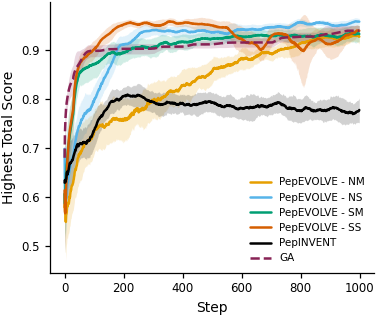

In [34]:
set_jcim_style()

TGA_COLOR = "#882255"

SETTINGS = ['nm', 'ns', 'sm', 'ss']
SETTING_TITLES = {'nm': 'NM', 'ns': 'NS', 'sm': 'SM', 'ss': 'SS'}
PEPEVOLVE_COLORS = {
    'nm': '#E69F00',
    'ns': '#56B4E9',
    'sm': '#009E73',
    'ss': '#D55E00',
}
PEPINVENT_COLOR = '#000000'

def compute_max_and_std_across_runs(base_dir, mode):
    """Returns (mean, std) of the per-step BEST score across 3 replicate runs."""
    run_maxes = []
    for run in [1, 2, 3]:
        df = load_single_run(base_dir, mode, run)
        if df is not None:
            run_maxes.append(df.groupby('Step')['total_score'].max())
    if not run_maxes:
        return None, None
    aligned = pd.concat(run_maxes, axis=1)
    return aligned.mean(axis=1), aligned.std(axis=1, ddof=1).fillna(0.0)

# Load per-step highest score with inter-replicate std
pepevolve_maxes = {}
pepevolve_max_stds = {}
for setting in SETTINGS:
    mode = f"{setting}_pepevolve"
    max_s, std_s = compute_max_and_std_across_runs(base_dir, mode)
    if max_s is not None:
        pepevolve_maxes[setting] = max_s
        pepevolve_max_stds[setting] = std_s

max_series_pepinvent, max_std_series_pepinvent = compute_max_and_std_across_runs(base_dir, "pepinvent")
max_series_tga, max_std_series_tga = compute_max_and_std_across_runs(base_dir, "traditional_ga")

fig, ax = plt.subplots(figsize=(SINGLE_COL_IN, H_MED))

legend_handles = {}

for setting in SETTINGS:
    if setting not in pepevolve_maxes:
        continue
    mean_series = pepevolve_maxes[setting]
    std_series = pepevolve_max_stds[setting]
    smooth_mean = mean_series.rolling(window=30, min_periods=1).mean()
    smooth_std = std_series.rolling(window=30, min_periods=1).mean()
    label = f"PepEVOLVE - {SETTING_TITLES[setting].upper()}"
    line, = ax.plot(
        smooth_mean.index,
        smooth_mean,
        linewidth=1.8,
        color=PEPEVOLVE_COLORS[setting],
        label=label,
        solid_capstyle='round'
    )
    ax.fill_between(
        smooth_mean.index,
        smooth_mean - smooth_std,
        smooth_mean + smooth_std,
        color=PEPEVOLVE_COLORS[setting],
        alpha=0.18,
        linewidth=0
    )
    legend_handles[f"pepevolve_{setting}"] = (line, label)

# PepINVENT
if max_series_pepinvent is not None:
    smooth_mean = max_series_pepinvent.rolling(window=30, min_periods=1).mean()
    smooth_std = max_std_series_pepinvent.rolling(window=30, min_periods=1).mean()
    label = "PepINVENT"
    line, = ax.plot(smooth_mean.index, smooth_mean, linewidth=1.8, color=PEPINVENT_COLOR, solid_capstyle='round')
    ax.fill_between(smooth_mean.index, smooth_mean - smooth_std, smooth_mean + smooth_std, color=PEPINVENT_COLOR, alpha=0.18, linewidth=0)
    legend_handles["pepinvent"] = (line, label)

# GA
if max_series_tga is not None:
    smooth_mean = max_series_tga.rolling(window=30, min_periods=1).mean()
    smooth_std = max_std_series_tga.rolling(window=30, min_periods=1).mean()
    label = "GA"
    line, = ax.plot(smooth_mean.index, smooth_mean, linewidth=1.8, color=TGA_COLOR, solid_capstyle='round', linestyle='--')
    ax.fill_between(smooth_mean.index, smooth_mean - smooth_std, smooth_mean + smooth_std, color=TGA_COLOR, alpha=0.18, linewidth=0)
    legend_handles["tga"] = (line, label)

ax.set_xlabel("Step")
ax.set_ylabel("Highest Total Score")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# ax.text(-0.15, 0.95, "B", transform=ax.transAxes,
#         va="bottom", ha="left", fontsize=11, fontweight="bold")

ordered_keys = [f"pepevolve_{s}" for s in SETTINGS] + ["pepinvent", "tga"]
ordered_handles = [legend_handles[k] for k in ordered_keys if k in legend_handles]
lines = [h[0] for h in ordered_handles]
labels = [h[1] for h in ordered_handles]

ax.legend(lines, labels, fontsize='small', loc='lower right', frameon=False)

plt.tight_layout()
plt.savefig(
    "../../figure_pdf/highest_score_linegraph_all_raw.pdf",
    bbox_inches='tight',
    dpi=600
)
plt.show()


In [22]:
def counts_mean_and_std_across_runs(base_dir, mode):
    """Returns (mean, std) of unique SMILES count across 3 runs at each step."""
    counts_per_run = []
    for run in [1, 2, 3]:
        df = load_single_run(base_dir, mode, run)
        if df is not None:
            counts_per_run.append(df.groupby("Step").size())
    if not counts_per_run:
        return None, None
    aligned = pd.concat(counts_per_run, axis=1)
    return aligned.mean(axis=1), aligned.std(axis=1, ddof=1).fillna(0.0)

modes = {
    "PepEVOLVE - NM": "nm_pepevolve",
    "PepEVOLVE - NS": "ns_pepevolve",
    "PepEVOLVE - SM": "sm_pepevolve",
    "PepEVOLVE - SS": "ss_pepevolve",
    "PepINVENT": "pepinvent",
    "GA": "traditional_ga",
}

counts_mean_df = {}
counts_std_df = {}
for label, mode in modes.items():
    mean_s, std_s = counts_mean_and_std_across_runs(base_dir, mode)
    if mean_s is not None:
        counts_mean_df[label] = mean_s
        counts_std_df[label] = std_s

counts_mean_df = pd.DataFrame(counts_mean_df).fillna(0).sort_index()
counts_std_df = pd.DataFrame(counts_std_df).fillna(0).sort_index()

/tmp/ipykernel_2175807/2461281410.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


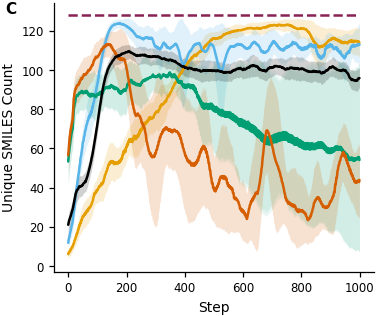

In [23]:
fig, ax = plt.subplots(figsize=(SINGLE_COL_IN, H_MED), constrained_layout=True)

for label in counts_mean_df.columns:
    mean_raw = counts_mean_df[label].dropna()
    mean_raw = mean_raw[mean_raw > 0]
    if mean_raw.empty:
        continue
    std_raw = counts_std_df[label].reindex(mean_raw.index).fillna(0.0)

    smooth_mean = mean_raw.rolling(window=30, min_periods=1, center=True).mean()
    smooth_std = std_raw.rolling(window=30, min_periods=1, center=True).mean()

    clr = color_map.get(label, "#999999")
    ls = '--' if label == "GA" else '-'

    ax.plot(smooth_mean.index, smooth_mean.values, linewidth=1.8, label=label, color=clr, solid_capstyle="round", linestyle=ls)
    ax.fill_between(smooth_mean.index, (smooth_mean - smooth_std).values, (smooth_mean + smooth_std).values, color=clr, alpha=0.18, linewidth=0)

ax.set_xlabel("Step")
ax.set_ylabel("Unique SMILES Count")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-0.15, 0.95, "C", transform=ax.transAxes,
        va="bottom", ha="left", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("../../figure_pdf/unique_smiles_count_vs_step.pdf", bbox_inches='tight')
plt.show()

In [31]:
import pickle as pkl

div_dir = "../../tools/notebook/diversity/output"

key_map_fps = {
    'crbp_neighbor_multi': 'PepEVOLVE - NM',
    'crbp_neighbor_single': 'PepEVOLVE - NS',
    'crbp_pepinvent': 'PepINVENT',
    'crbp_self_multi': 'PepEVOLVE - SM',
    'crbp_self_single': 'PepEVOLVE - SS',
    'traditional_ga': 'GA',
}

records = []
for key, label in key_map_fps.items():
    path = os.path.join(div_dir, f"{key}_diversity.pkl")
    if not os.path.exists(path):
        print(f"  Missing: {path}")
        continue
    with open(path, "rb") as f:
        div_df = pkl.load(f)
    for _, row in div_df.iterrows():
        rep = row["run"] if "run" in div_df.columns else 1
        records.append({"run": label, "rep": rep, "Step": row["Step"], "diversity": row["diversity"]})

df_div = pd.DataFrame(records).sort_values(["run", "Step", "rep"]).reset_index(drop=True)
reps_per_method = df_div.groupby("run")["rep"].nunique()
print(f"Loaded diversity data: {df_div['run'].nunique()} methods, {len(df_div)} rows")
print("Replicates per method:")
print(reps_per_method.to_string())


Loaded diversity data: 6 methods, 17759 rows
Replicates per method:
run
GA                3
PepEVOLVE - NM    3
PepEVOLVE - NS    3
PepEVOLVE - SM    3
PepEVOLVE - SS    3
PepINVENT         3


/tmp/ipykernel_2175807/1858137745.py:29: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


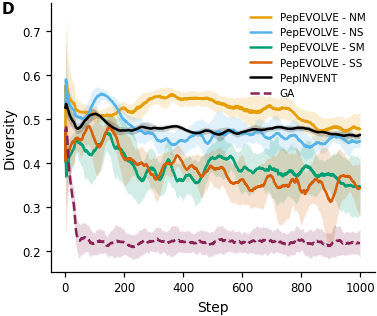

In [32]:
fig, ax = plt.subplots(figsize=(SINGLE_COL_IN, H_MED), constrained_layout=True)

window = 30
plot_order = ["PepEVOLVE - NM", "PepEVOLVE - NS", "PepEVOLVE - SM", "PepEVOLVE - SS", "PepINVENT", "GA"]

for run in plot_order:
    dfr = df_div[df_div["run"] == run].sort_values("Step").copy()
    if dfr.empty:
        continue
    grouped = dfr.groupby("Step")["diversity"].agg(["mean", "std"]).reset_index()
    grouped["std"] = grouped["std"].fillna(0.0)
    smooth_mean = grouped["mean"].rolling(window=window, min_periods=1).mean()
    smooth_std = grouped["std"].rolling(window=window, min_periods=1).mean()

    clr = color_map.get(run, "#999999")
    ls = '--' if run == "GA" else '-'

    ax.plot(grouped["Step"], smooth_mean, label=run, color=clr, linewidth=1.8, solid_capstyle="round", linestyle=ls)
    ax.fill_between(grouped["Step"], (smooth_mean - smooth_std).values, (smooth_mean + smooth_std).values, color=clr, alpha=0.18, linewidth=0)

ax.set_xlabel("Step")
ax.set_ylabel("Diversity")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(-0.15, 0.95, "D", transform=ax.transAxes,
        va="bottom", ha="left", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize='small')

plt.tight_layout()
plt.savefig("../../figure_pdf/diversity_vs_step.pdf", bbox_inches='tight')
plt.show()

In [26]:
import numpy as np
import matplotlib.pyplot as plt

set_jcim_style()

SINGLE_COL_IN = 4
H_MED   = 3.4

def get_unique_avg_scores(base_dir, mode):
    combined = load_runs(base_dir, mode)
    if combined is None:
        return None
    return combined.groupby('SMILES')['total_score'].mean()

pepinvent_scores       = get_unique_avg_scores(base_dir, 'pepinvent')
self_multi_scores      = get_unique_avg_scores(base_dir, 'sm_pepevolve')
self_single_scores     = get_unique_avg_scores(base_dir, 'ss_pepevolve')
neighbor_single_scores = get_unique_avg_scores(base_dir, 'ns_pepevolve')
neighbor_multi_scores  = get_unique_avg_scores(base_dir, 'nm_pepevolve')
tga_scores             = get_unique_avg_scores(base_dir, 'traditional_ga')

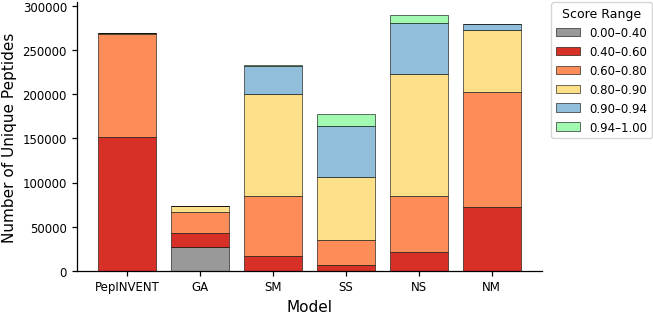

In [27]:
bins = np.array([0.0, 0.4, 0.6, 0.8, 0.9, 0.94, 1.0])
labels = [f"{bins[i]:.2f}–{bins[i+1]:.2f}" for i in range(len(bins)-1)]
n_bins = len(labels)

pepinvent_hist, _        = np.histogram(pepinvent_scores, bins=bins)
self_multi_hist, _       = np.histogram(self_multi_scores, bins=bins)
self_single_hist, _      = np.histogram(self_single_scores, bins=bins)
neighbor_single_hist, _  = np.histogram(neighbor_single_scores, bins=bins)
neighbor_multi_hist, _   = np.histogram(neighbor_multi_scores, bins=bins)
tga_hist, _              = np.histogram(tga_scores, bins=bins) if tga_scores is not None else (np.zeros(n_bins, dtype=int), None)

data = np.vstack([
    pepinvent_hist,
    tga_hist,
    self_multi_hist,
    self_single_hist,
    neighbor_single_hist,
    neighbor_multi_hist
])

colors_stack = ['#999999', '#d73027', '#fc8d59', '#fee08b', '#91bfdb', '#a2fab1']

datasets = ['PepINVENT', 'GA', 'SM', 'SS', 'NS', 'NM']
x_pos = np.arange(len(datasets))
bottom = np.zeros(len(datasets), dtype=int)

fig, ax = plt.subplots(figsize=(SINGLE_COL_IN*2, H_MED))

for i in range(n_bins):
    ax.bar(
        x_pos, data[:, i],
        bottom=bottom,
        label=labels[i],
        color=colors_stack[i],
        edgecolor='black',
        linewidth=0.4
    )
    bottom += data[:, i]

ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Number of Unique Peptides', fontsize=11)
ax.set_xticks(x_pos, datasets, rotation=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(title='Score Range', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig(
    "../../figure_pdf/average_score_stacked_bar.pdf",
    dpi=600, bbox_inches='tight'
)
plt.show()

GA run 1 — top peptide
  Step:   854
  Score:  0.9518
  SMILES: N2[C@@H](Cc1ccc(O)cc1)C(=O)N1[C@@H](CCC1)C(=O)N(C)[C@@H](CN(C)C(=O)N[C@H]1CC(=O)N(C)C1=O)C(=O)N(C)[C@@H]([C@H](Cc1n(CCOC)cnn1)C)C(=O)N[C@@H](CO)C(=O)N[C@@H](Cc1ccc(O)cc1)C(=O)N[C@@H](CCCNC(=N)N)C(=O)N(C)[C@@H](CN(C(C)C)C(=O)N1CCC[C@H]1CO)C(=O)N[C@@H]([C@@H](C)O)C2(=O)


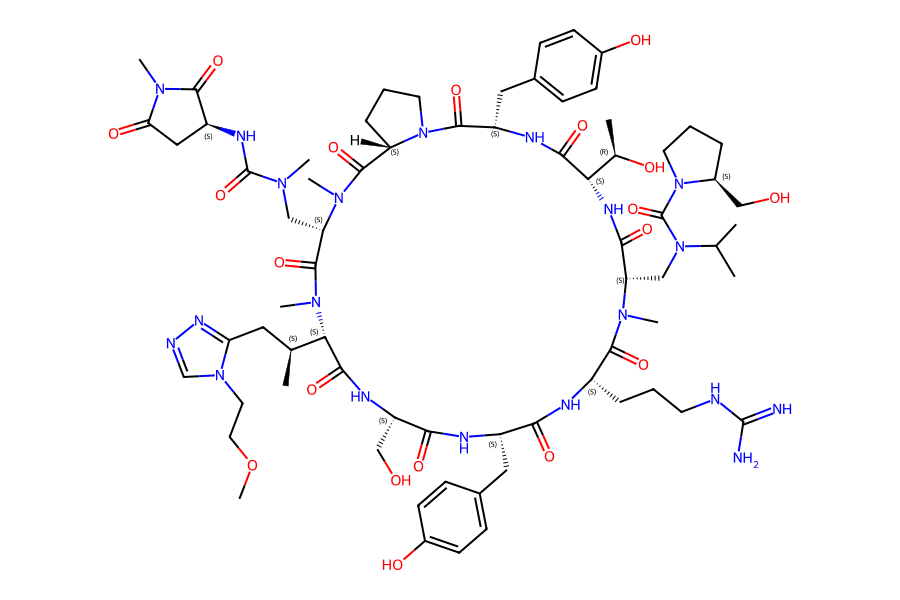

In [28]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

# Top-scoring peptide from GA run 1
ga1 = pd.read_csv(os.path.join(base_dir, "traditional_ga1", "results_evolving_step1000.csv"))
top_row = ga1.loc[ga1["total_score"].idxmax()]
top_smiles = top_row["SMILES"]

print("GA run 1 — top peptide")
print(f"  Step:   {int(top_row['Step'])}")
print(f"  Score:  {top_row['total_score']:.4f}")
print(f"  SMILES: {top_smiles}")

mol = Chem.MolFromSmiles(top_smiles)
drawer = rdMolDraw2D.MolDraw2DSVG(900, 600)
drawer.drawOptions().addStereoAnnotation = True
rdMolDraw2D.PrepareAndDrawMolecule(drawer, mol)
drawer.FinishDrawing()
SVG(drawer.GetDrawingText())
